# Structured MDN / FiLM：训练诊断与保守调整

原始运行结果保留在 `mdn-year2000.ipynb`；本文件是独立实验副本。

原运行的 18 个窗口中，Structured K3 有 7 个、两个 FiLM 各有 9 个在前两轮达到最佳验证 NLL。
训练 NLL 继续下降，说明模型在拟合训练集；这不是“完全没有学习”的证据。

本版本默认保留原学习率 0.003、模型结构、dropout、权重衰减、训练上限、早停与 72/12/12 时间窗口。
本地三个窗口对照没有证明降低学习率一致有效，因此 slow_lr 仅作为显式对照选项，不默认开启。
新增 epoch 0 和早期四分之一轮检查点、同为 eval 模式的训练/验证 NLL、逐月验证诊断、分批预测、每窗口保存。
最佳模型可来自 epoch 0 或非整数 epoch；不会为了“多训练”强制跳过早期最佳模型。

先 `run_test="quick"` 从头运行检查接口，再改为 `"full"` 重启并运行。
默认只运行 Structured K3 与两个 FiLM，避免重复运行线性模型和 Rolling Normal。
所有候选选择只使用验证集。这里只改善实验和训练流程，不承诺样本外收益。


## 本地短程对照：尚无统一获胜的参数

使用项目真实数据，Structured K3，窗口 0 / 2 / 16，单种子，最多 10 轮。下面均为最佳验证 NLL（越低越好）。

| 窗口 | 原 LR | 低 LR | 原 LR + 绝对波动 | 低 LR + 绝对波动 |
|---|---:|---:|---:|---:|
| 0 | -0.816284 | -0.816465 | -0.907156 | -0.850109 |
| 2 | -0.399860 | -0.378577 | -0.364670 | -0.383888 |
| 16 | -0.492887 | -0.458970 | -0.459008 | -0.447983 |

窗口 2、16 的原 LR 最优点均在第 0.5 轮，因此新增轮内检查点有实际依据。
更低学习率可能需要更长训练；绝对波动实验改变了输入维度和初始化。此处没有多种子或完整样本外效果验证。
保留默认原 LR 和原输入，先测量轮内模型选择的作用。不能把更晚的最佳 epoch 当成改进标准。

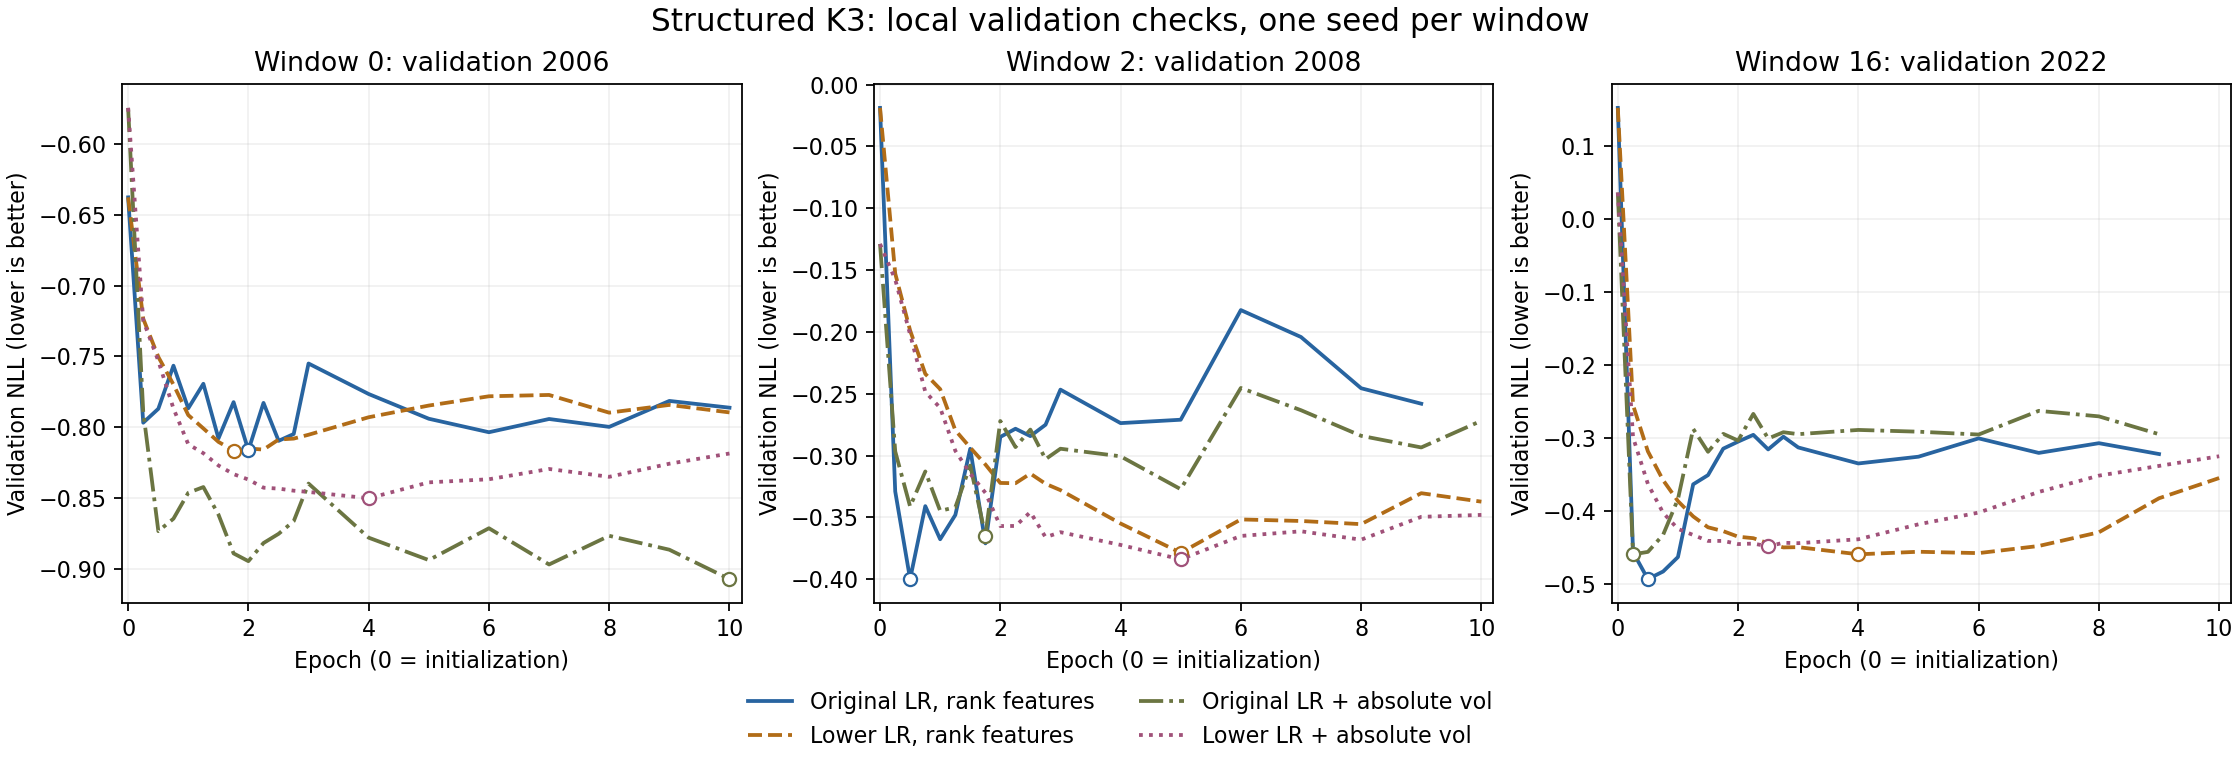


In [ ]:
from pathlib import Path
import os, json, math, copy, random, time
from datetime import datetime
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from scipy.stats import norm, t as student_t
import matplotlib.pyplot as plt
from IPython.display import display

# Kaggle: attach the same mdndata-1990 dataset as in the original run.
DATA_DIR = (Path('/kaggle/input/datasets/jianbinchenuc/mdndata-1990')
            if Path('/kaggle').exists() else Path('../data'))
OUTPUT_ROOT = Path('/kaggle/working') if Path('/kaggle').exists() else Path('../output')
micro_data = pd.read_parquet(DATA_DIR / 'micro_data.parquet')
macro_data = pd.read_parquet(DATA_DIR / 'macro_data.parquet')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print('Raw data:', micro_data.shape, macro_data.shape)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


In [ ]:
# Experiment controls. Change one factor at a time.
run_test = 'quick'             # 'quick': two epochs, first two selected windows; 'full': real experiment
training_profile = 'original_lr'  # 'original_lr' or 'slow_lr'; slower was not uniformly better
selected_windows = None       # None = all 18; e.g. [0, 2, 16] for a diagnostic subset
model_names = ['structured', 'structured_film_sigma', 'structured_film_all']
random_seed = 42
initial_train_months, val_months, test_months = 72, 12, 12
industry_type = 'ffi12'
windows_type, weights_type = 'rolling', 'month_equal'
micro_normalize, normalization_eps = 'rank', 1e-8
sigma_floor, dropout_rate = 0.005, 0.05
batch_size, inference_batch_size = 1024, 8192
lr = {'original_lr': 3e-3, 'slow_lr': 3e-4}[training_profile]
macro_lr_factor = 1.0         # keep equal learning rates for a clean first comparison
mdn_weight_decay = 1e-4       # unchanged from original
mdn_max_epochs, mdn_patience = 500, 50
# Patience counts whole epochs, unchanged from the original run.
early_checks_per_epoch, early_check_epochs = 4, 3
include_absolute_vol = False  # optional second experiment; keep False for learning-rate comparison
ALPHAS = (0.05, 0.10)
ALPHA_SUFFIX = {0.05: '5', 0.10: '10'}
seed_everything(random_seed)
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S_%f')
path = OUTPUT_ROOT / f'mdn_{training_profile}_{run_test}_{timestamp}'
path.mkdir(parents=True, exist_ok=True)
config = {k: globals()[k] for k in [
    'run_test', 'training_profile', 'selected_windows', 'model_names', 'random_seed',
    'initial_train_months', 'val_months', 'test_months', 'industry_type',
    'windows_type', 'weights_type', 'micro_normalize', 'sigma_floor', 'dropout_rate',
    'batch_size', 'inference_batch_size', 'lr', 'macro_lr_factor', 'mdn_weight_decay',
    'mdn_max_epochs', 'mdn_patience', 'early_checks_per_epoch', 'early_check_epochs',
    'include_absolute_vol']}
config.update(torch_version=torch.__version__, numpy_version=np.__version__,
              pandas_version=pd.__version__, data_dir=str(DATA_DIR), device=str(device))
(path / 'config.json').write_text(json.dumps(config, indent=2))
print('Outputs:', path)


## 数据：保持原样本和时间切分
可选绝对波动通道默认关闭。开启时，它使用截至当月的历史波动与固定参考尺度，不做月度截面 rank。

In [ ]:
# =========================================================
# 核心修复：强制对齐“日历月网格” (Resampling to Continuous Grid)
# =========================================================
print(" -> Reindexing panel data to a continuous monthly grid...")

# 2. 将日期设置为 Index，为 Pandas 的重采样做准备
micro_data = micro_data.set_index('mthcaldt')

# 3. ★ 核心魔法：按 permno 分组，按月 ('ME' 或 'M') 重新采样
# 只要两个日期之间有断层，Pandas 就会自动插入缺失的月份，并将那一行的值设为 NaN
micro_data = micro_data.groupby('permno').resample('ME').asfreq().drop(columns=['permno']).reset_index()
print(" -> Reindexing completed. New shape:", micro_data.shape)
# micro_data = micro_data.drop(columns=['linkdt', 'linkenddt', 'public_date'], errors='ignore') # 删除不再需要的列

In [ ]:
# =========================================================
# 数据预处理
# =========================================================
micro_cols = ['mthret', 'mthprc', 'bm', 'evm', 'ps', 'pcf', 'opmad', 'cfm', 'roe', 'gprof', 'debt_at', 
              'short_debt', 'cash_ratio', 'curr_ratio', 'at_turn', 'rd_sale', 'accrual']

micro_data = micro_data.sort_values(['permno', 'mthcaldt']).reset_index(drop=True)
# 1. 计算 t+1 收益率
micro_data['target_ret_final'] = micro_data.groupby('permno')['mthret'].shift(-1)

# 2. 计算过去 12 个月动量（跳过近 1 月，滚动 11 月）
micro_data['log_ret'] = np.log1p(micro_data['mthret'])
micro_data['MOM12m'] = micro_data.groupby('permno')['log_ret'].transform(
    lambda x: x.shift(1).rolling(window=11, min_periods=6).sum()
)
micro_data['MOM12m'] = np.exp(micro_data['MOM12m']) - 1
micro_data = micro_data.drop(columns=['log_ret'])

# 3. 在完整微观时间序列上计算 12 个月滚动均值和标准差
micro_data['mu_bench'] = micro_data.groupby('permno')['mthret'].transform(
    lambda x: x.rolling(12, min_periods=6).mean()
)
micro_data['sigma_bench'] = micro_data.groupby('permno')['mthret'].transform(
    lambda x: x.rolling(12, min_periods=6).std()
)

micro_data = micro_data[micro_data[['target_ret_final', 'mthret', 'shrout', 'gvkey']].notna().all(axis=1)]
print(" -> After filtering, new shape:", micro_data.shape)

micro_data['turnover'] = micro_data['mthvol'] / (micro_data['shrout'] * 1000)

# 对mthcap和mthvol取log
micro_data['mthcap_log'] = np.log(micro_data['mthcap'])

derived_micro_cols = ['MOM12m', 'mu_bench', 'sigma_bench', 'turnover', 'mthcap_log']
micro_cols = micro_cols + derived_micro_cols

# 剔除价格低于 5 美元的股票
micro_data = micro_data[micro_data['mthprc'] >= 5].copy()


# 剔除金融行业 (SIC 代码 6000 至 6999) 
micro_data['siccd']=micro_data['siccd'].astype('Int64')
print(f"Total rows before removing financial sector: {len(micro_data)}")
micro_data=micro_data[(micro_data['siccd'] < 6000) | (micro_data['siccd'] > 6999)]
print(f"Total rows after removing financial sector: {len(micro_data)}")
micro_data=micro_data.drop(columns=['siccd'])
print(f"Total duplicates found after merging: {micro_data.duplicated(subset=['permno', 'mthcaldt'], keep=False).sum()}")

# 先用“月份 + 行业”中位数填充，再用当月全市场中位数补充, 最后用0填充缺失值
for col in micro_cols:
    industry_median = micro_data.groupby(['mthcaldt', industry_type])[col].transform('median')
    market_median = micro_data.groupby('mthcaldt')[col].transform('median')
    micro_data[col] = micro_data[col].fillna(industry_median).fillna(market_median).fillna(0)

# 将 industry_type 缺失值填充为 0，并转换为整数类型
micro_data[industry_type] = micro_data[industry_type].fillna(0).astype(int)

micro_data = micro_data[
    micro_data['mthcaldt'].between('2000-01-31', '2024-12-31')
].reset_index(drop=True)

pd.concat([micro_data.head(5), micro_data.tail(5)])


In [ ]:
# =========================================================
# 1. Validate the cleaned micro table and normalize explicit features
# =========================================================
micro_data = micro_data[['permno', 'mthcaldt', industry_type, 'target_ret_final'] + micro_cols].copy()
micro_data['mthcaldt'] = pd.to_datetime(micro_data['mthcaldt']) + pd.offsets.MonthEnd(0)

# Preserve the historical scale before cross-sectional normalization.
absolute_log_vol = np.log(micro_data['sigma_bench'].clip(lower=1e-4) / 0.1)

# 每月截面 1%/99% winsorize
for col in micro_cols:
    grouped = micro_data.groupby("mthcaldt")[col]
    lower = grouped.transform("quantile", q=0.01)
    upper = grouped.transform("quantile", q=0.99)
    micro_data[col] = micro_data[col].clip(lower=lower, upper=upper)

if micro_normalize == 'rank':
    micro_norm = (
        micro_data.groupby('mthcaldt')[micro_cols].rank(pct=True) * 2.0 - 1.0
    )
elif micro_normalize == 'normal':
    monthly_mean = micro_data.groupby('mthcaldt')[micro_cols].transform('mean')
    monthly_std = micro_data.groupby('mthcaldt')[micro_cols].transform('std')
    micro_norm = (
        micro_data[micro_cols] - monthly_mean
    ) / (monthly_std + normalization_eps)
elif micro_normalize == 'none':
    micro_norm = micro_data[micro_cols]
else:
    raise ValueError("micro_normalize must be 'normal', 'rank', or 'none'")

micro_data[micro_cols] = micro_norm.fillna(0.0).to_numpy()

if include_absolute_vol:
    micro_data['log_sigma_absolute'] = absolute_log_vol
    micro_cols = micro_cols + ['log_sigma_absolute']

micro_data = micro_data.sort_values(['mthcaldt', 'permno']).reset_index(drop=True)

print('Micro model panel:', micro_data.shape)

display(pd.concat([micro_data.head(3), micro_data.tail(3)]))

In [ ]:
def standardize_macro_window(
    train_df, val_df, test_df, macro_cols,
    date_col="mthcaldt",
):
    # 每个月的宏观数据只保留一行，避免按公司数量加权
    train_macro = (
        train_df[[date_col] + macro_cols]
        .drop_duplicates()
        .sort_values(date_col)
    )

    # 同一个月不应该出现两组不同的宏观数据
    if train_macro[date_col].duplicated().any():
        raise ValueError("同一个月份存在不一致的宏观数据。")

    train_median = train_macro[macro_cols].median()

    if train_median.isna().any():
        bad_cols = train_median[train_median.isna()].index.tolist()
        raise ValueError(f"Training 中完全缺失的宏观变量: {bad_cols}")

    train_x = train_macro[macro_cols].fillna(train_median)
    train_mean = train_x.mean()

    train_std = train_x.std(ddof=0)
    train_std = train_std.mask(train_std < 1e-8, 1.0)

    def transform(df):
        return (
            df[macro_cols].fillna(train_median) - train_mean
        ) / train_std

    scaler = {
        "median": train_median,
        "mean": train_mean,
        "std": train_std,
    }

    return (
        transform(train_df),
        transform(val_df),
        transform(test_df),
        scaler,
    )

In [ ]:
# =========================================================
# 3. 最后合并标准化后的 Micro 和 Macro
# =========================================================
macro_cols = [col for col in macro_data.columns if col != 'mthcaldt']
macro_data['mthcaldt'] = pd.to_datetime(macro_data['mthcaldt']) + pd.offsets.MonthEnd(0)
macro_data = macro_data.sort_values('mthcaldt').reset_index(drop=True)

processed_df = (
    micro_data
    .merge(macro_data, on='mthcaldt', how='left', validate='many_to_one')
    .sort_values(['mthcaldt', 'permno'])
    .reset_index(drop=True)
)

print(f'Data preprocessing complete. Final shape: {processed_df.shape}')
print(f'Micro features: {len(micro_cols)}; Macro features: {len(macro_cols)}')

pd.concat([processed_df.head(5), processed_df.tail(5)])
assert not processed_df.duplicated(['permno', 'mthcaldt']).any()
assert np.isfinite(processed_df[micro_cols + ['target_ret_final']].to_numpy(dtype=float)).all()


In [ ]:
def tensor_batch_indices(length, batch_size, device, shuffle=True):
    if shuffle:
        indices = torch.randperm(length, device=device)
    else:
        indices = torch.arange(length, device=device)
    for start in range(0, length, batch_size):
        yield indices[start:start + batch_size] 

In [ ]:
# ==========================================
# 2. 轻量级时间窗口生成器
# ==========================================
class DataWindowGenerator:
    """
    仅负责按时间切分数据，向模型输送 Train/Val/Test 窗口
    """
    def __init__(self, df, date_col='mthcaldt'):
        self.df = df
        self.date_col = date_col

    def expanding_window_generator(self, initial_train_months=180, val_months=12, test_months=12):
        dates = np.sort(self.df[self.date_col].unique())
        
        start_idx = 0
        current_split_idx = initial_train_months
        
        while current_split_idx + val_months  < len(dates):
            train_dates = dates[start_idx : current_split_idx]
            val_dates = dates[current_split_idx : current_split_idx + val_months]
            test_dates = dates[current_split_idx + val_months : current_split_idx + val_months + test_months]
            
            train_data = self.df[self.df[self.date_col].isin(train_dates)]
            val_data = self.df[self.df[self.date_col].isin(val_dates)]
            test_data = self.df[self.df[self.date_col].isin(test_dates)]
            
            window_info = {
                'train': (pd.Timestamp(train_dates[0]).strftime('%Y-%m'), pd.Timestamp(train_dates[-1]).strftime('%Y-%m')),
                'val': (pd.Timestamp(val_dates[0]).strftime('%Y-%m'), pd.Timestamp(val_dates[-1]).strftime('%Y-%m')),
                'test': (pd.Timestamp(test_dates[0]).strftime('%Y-%m'), pd.Timestamp(test_dates[-1]).strftime('%Y-%m'))
            }
            yield window_info, train_data, val_data, test_data
            current_split_idx += test_months
            
    # （固定 15 年滚动窗口版）
    def rolling_window_generator(self, train_months=180, val_months=12, test_months=12):
        """
        固定训练窗口长度的滚动窗口生成器。
        参数：
        train_months: 固定训练集包含的月数。默认 180 个月(15年)。
        """
        # 确保日期是有序的
        dates = np.sort(self.df[self.date_col].unique())
        
        # 初始时，当前切分点就是训练集的总长度（180个月）
        current_split_idx = train_months
        
        # 只要后面还有足够的月份可以分给验证集和测试集，就继续滚动
        while current_split_idx + val_months < len(dates):
            
            # 【核心修改点】让训练集的起点跟着一起滚动，确保长度永远等于 train_months
            start_idx = current_split_idx - train_months
            
            # 切分对应的日期数组
            train_dates = dates[start_idx : current_split_idx]
            val_dates = dates[current_split_idx : current_split_idx + val_months]
            test_dates = dates[current_split_idx + val_months : current_split_idx + val_months + test_months]
            
            # 根据日期过滤出对应的数据集
            train_data = self.df[self.df[self.date_col].isin(train_dates)]
            val_data = self.df[self.df[self.date_col].isin(val_dates)]
            test_data = self.df[self.df[self.date_col].isin(test_dates)]
            
            window_info = {
                'train': (pd.Timestamp(train_dates[0]).strftime('%Y-%m'), pd.Timestamp(train_dates[-1]).strftime('%Y-%m')),
                'val': (pd.Timestamp(val_dates[0]).strftime('%Y-%m'), pd.Timestamp(val_dates[-1]).strftime('%Y-%m')),
                'test': (pd.Timestamp(test_dates[0]).strftime('%Y-%m'), pd.Timestamp(test_dates[-1]).strftime('%Y-%m'))
            }
            yield window_info, train_data, val_data, test_data
            
            # 向前推進一个测试窗口的长度
            current_split_idx += test_months

def make_window_generator(panel):
    generator = DataWindowGenerator(df=panel, date_col="mthcaldt")

    if windows_type == "expanding":
        return generator.expanding_window_generator(
            initial_train_months=initial_train_months,
            val_months=val_months,
            test_months=test_months,
        )

    return generator.rolling_window_generator(
        train_months=initial_train_months,
        val_months=val_months,
        test_months=test_months,
    )

In [ ]:
# ==========================================
# Sample weights: prevent months with more listed stocks from dominating
# ==========================================
def calculate_sample_weights(df_dates, mode='month_equal', half_life_months=36):
    dates = pd.to_datetime(df_dates).reset_index(drop=True)
    if mode == 'uniform':
        weights = np.ones(len(dates), dtype=np.float64)
    elif mode in {'month_equal', 'time_decay'}:
        month_counts = dates.groupby(dates).transform('size').to_numpy(dtype=float)
        weights = 1.0 / np.maximum(month_counts, 1.0)
        if mode == 'time_decay':
            max_date = dates.max()
            months_diff = (
                (max_date.year - dates.dt.year) * 12
                + (max_date.month - dates.dt.month)
            ).to_numpy(dtype=float)
            weights *= np.power(0.5, months_diff / half_life_months)
    else:
        raise ValueError("weights_type must be 'uniform', 'month_equal', or 'time_decay'")
    weights = weights / weights.mean()
    return weights.astype(np.float32)

# ==========================================
# 将完整面板转成设备端 Tensor
# ==========================================
def make_device_tensors(panel):
    X_micro = torch.from_numpy(
        panel[micro_cols].to_numpy(dtype=np.float32, copy=True)
    ).to(device)

    industry = torch.from_numpy(
        panel[industry_type].to_numpy(dtype=np.int64, copy=True)
    ).to(device)

    target = torch.from_numpy(
        panel["target_ret_final"].to_numpy(dtype=np.float32, copy=True)
    ).to(device)

    return X_micro, industry, target

## 模型与训练
网络结构和 FiLM 初始化保持原样。新增的检查点记录可回答：训练前有多好、第一轮内部是否更好、训练与验证是否分化。

In [ ]:
# ==========================================
# 所有 MDN 共用的加权 NLL
# ==========================================
def mdn_nll_loss_weighted(pi_logits, mu, sigma, nu, target, weights, dist_type="normal",):
    target = target.reshape(-1, 1)
    weights = weights.reshape(-1)

    log_pi = torch.log_softmax(pi_logits, dim=1)

    if dist_type == "normal":
        dist = torch.distributions.Normal(mu, sigma)
    elif dist_type == "t":
        dist = torch.distributions.StudentT(df=nu, loc=mu, scale=sigma,)
    else:
        raise ValueError("dist_type must be 'normal' or 't'")

    log_component = dist.log_prob(target.expand_as(mu))
    observation_nll = -torch.logsumexp( log_pi + log_component, dim=1,)

    return (observation_nll * weights).sum() / weights.sum().clamp_min(1e-12)

In [ ]:
# ==========================================
# 所有 MDN 共用的 Validation
# ==========================================
def evaluate_mdn(model, X_macro, X_micro, X_industry, target, weights, batch_size,):
    model.eval()
    loss_numerator = 0.0
    weight_sum = 0.0

    with torch.no_grad():
        for batch_idx in tensor_batch_indices(len(target), batch_size, X_macro.device, shuffle=False):
            b_macro = X_macro[batch_idx]
            b_micro = X_micro[batch_idx]
            b_industry = X_industry[batch_idx]
            b_y = target[batch_idx]
            b_w = weights[batch_idx]

            pi_logits, mu, sigma, nu = model(b_macro, b_micro, b_industry)

            loss = mdn_nll_loss_weighted(pi_logits, mu, sigma, nu, b_y, b_w, dist_type=model.dist_type)

            batch_weight = float(b_w.sum().item())
            loss_numerator += loss.item() * batch_weight
            weight_sum += batch_weight

    return loss_numerator / max(weight_sum, 1e-12)

In [ ]:
# ==========================================
# Structured MDN：Macro → pi，Micro + Industry → mu 和 sigma
# ==========================================
class StructuredMDN(nn.Module):
    def __init__(self, macro_dim, micro_dim, num_industries, ind_emb_dim=6, macro_hidden_dim=32,
                 micro_hidden_dim=64, head_dim=8, num_components=3, dropout_rate=0.05,
                 dist_type="normal"):
        super().__init__()
        self.num_components = num_components
        self.dist_type = dist_type

        self.ind_embedding = nn.Embedding(num_industries, ind_emb_dim)

        self.macro_net = nn.Sequential(
            nn.Linear(macro_dim, macro_hidden_dim),
            nn.LayerNorm(macro_hidden_dim),
            nn.ELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(macro_hidden_dim, macro_hidden_dim // 2),
            nn.LayerNorm(macro_hidden_dim // 2),
            nn.ELU(),
        )

        self.micro_net = nn.Sequential(
            nn.Linear(micro_dim + ind_emb_dim, micro_hidden_dim),
            nn.LayerNorm(micro_hidden_dim),
            nn.ELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(micro_hidden_dim, micro_hidden_dim // 2),
            nn.LayerNorm(micro_hidden_dim // 2),
            nn.ELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(micro_hidden_dim // 2, head_dim),
            nn.LayerNorm(head_dim),
            nn.ELU(),
        )

        self.pi_head = nn.Linear(macro_hidden_dim // 2, num_components) if num_components > 1 else None
        self.mu_head = nn.Linear(head_dim, num_components)
        self.sigma_head = nn.Linear(head_dim, num_components)
        self.nu_head = nn.Linear(head_dim, num_components) if dist_type == "t" else None

        nn.init.normal_(self.ind_embedding.weight, mean=0.0, std=0.05)
        nn.init.xavier_normal_(self.mu_head.weight, gain=0.1)
        nn.init.zeros_(self.mu_head.bias)
        nn.init.xavier_normal_(self.sigma_head.weight, gain=0.1)
        nn.init.constant_(self.sigma_head.bias, -2.35)

        if self.pi_head is not None:
            nn.init.zeros_(self.pi_head.weight)
            nn.init.zeros_(self.pi_head.bias)

        if self.nu_head is not None:
            nn.init.xavier_normal_(self.nu_head.weight, gain=0.1)
            nn.init.constant_(self.nu_head.bias, 5.0)

    def forward(self, x_macro, x_micro, x_industry):
        h_macro = self.macro_net(x_macro)

        if self.pi_head is None:
            pi_logits = h_macro.new_zeros((len(h_macro), 1))
        else:
            pi_logits = self.pi_head(h_macro)

        industry_embedding = self.ind_embedding(x_industry)
        h_micro = self.micro_net(torch.cat([x_micro, industry_embedding], dim=1))

        mu = self.mu_head(h_micro)
        sigma = F.softplus(self.sigma_head(h_micro)) + sigma_floor
        nu = F.softplus(self.nu_head(h_micro)) + 2.01 if self.nu_head is not None else None

        return pi_logits, mu, sigma, nu

In [ ]:
# ==========================================
# Structured FiLM MDN：Macro → pi，Micro + Industry → mu 和 sigma，Macro → FiLM → Micro
# ==========================================
class StructuredFiLMMDN(StructuredMDN):
    def __init__(
        self,
        macro_dim,
        micro_dim,
        num_industries,
        ind_emb_dim=6,
        macro_hidden_dim=16,
        micro_hidden_dim=64,
        head_dim=8,
        num_components=3,
        dropout_rate=0.05,
        dist_type="normal",
        film_target="sigma",  # "sigma" 或 "all"
        film_strength=0.1,
    ):
        super().__init__(
            macro_dim=macro_dim,
            micro_dim=micro_dim,
            num_industries=num_industries,
            ind_emb_dim=ind_emb_dim,
            macro_hidden_dim=macro_hidden_dim,
            micro_hidden_dim=micro_hidden_dim,
            head_dim=head_dim,
            num_components=num_components,
            dropout_rate=dropout_rate,
            dist_type=dist_type,
        )

        if film_target not in {"sigma", "all"}:
            raise ValueError("film_target must be 'sigma' or 'all'")

        self.film_target = film_target
        self.film_strength = film_strength

        # 复用 macro_net 的输出，减少额外参数。
        self.film_head = nn.Linear(
            macro_hidden_dim // 2,
            2 * head_dim,
        )

        # 初始状态是恒等变换：h_film = h_micro。
        nn.init.zeros_(self.film_head.weight)
        nn.init.zeros_(self.film_head.bias)

    def forward(self, x_macro, x_micro, x_industry):
        h_macro = self.macro_net(x_macro)

        if self.pi_head is None:
            pi_logits = h_macro.new_zeros(
                (len(h_macro), 1)
            )
        else:
            pi_logits = self.pi_head(h_macro)

        industry_embedding = self.ind_embedding(x_industry)
        h_micro = self.micro_net(
            torch.cat([x_micro, industry_embedding], dim=1)
        )

        gamma_raw, beta_raw = self.film_head(h_macro).chunk(
            2, dim=1
        )

        delta_gamma = (
            self.film_strength * torch.tanh(gamma_raw)
        )
        beta = self.film_strength * torch.tanh(beta_raw)

        h_film = (1.0 + delta_gamma) * h_micro + beta

        h_mu = (
            h_film if self.film_target == "all" else h_micro
        )

        mu = self.mu_head(h_mu)
        sigma = (
            F.softplus(self.sigma_head(h_film))
            + sigma_floor
        )

        # 第一版保持自由度来自未调制的 micro 表征，
        # 避免一次引入过多变化。
        nu = (
            F.softplus(self.nu_head(h_micro)) + 2.01
            if self.nu_head is not None
            else None
        )

        return pi_logits, mu, sigma, nu

In [ ]:
def train_mdn(
    model, X_train_macro, X_train_micro, X_train_industry, y_train, w_train,
    X_val_macro, X_val_micro, X_val_industry, y_val, w_val,
    epochs=120, batch_size=1024, lr=3e-4, patience=20,
):
    # Epoch 0 is a real candidate. Never force training past the best checkpoint.
    if run_test == 'quick':
        epochs = 2
    slow, main = [], []
    for name, param in model.named_parameters():
        (slow if name.startswith(('macro_net.', 'pi_head.', 'film_head.')) else main).append(param)
    groups = [{'params': main, 'lr': lr}]
    if slow:
        groups.append({'params': slow, 'lr': lr * macro_lr_factor})
    optimizer = optim.AdamW(groups, weight_decay=mdn_weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5,
        threshold=1e-4, threshold_mode='abs', min_lr=1e-6,
    )
    def score_training():
        return evaluate_mdn(model, X_train_macro, X_train_micro,
                            X_train_industry, y_train, w_train, inference_batch_size)
    def score_validation():
        return evaluate_mdn(model, X_val_macro, X_val_micro,
                            X_val_industry, y_val, w_val, inference_batch_size)
    records = []
    initial_train, initial_val = score_training(), score_validation()
    if not np.isfinite([initial_train, initial_val]).all():
        raise RuntimeError('Non-finite epoch-0 NLL; inspect input values and initial scales.')
    best_val = initial_val
    best_state = copy.deepcopy(model.state_dict())
    best_epoch, best_step = 0.0, 0
    significant_best, stale_epochs = best_val, 0
    steps_per_epoch = math.ceil(len(y_train) / batch_size)
    global_step = 0
    train_history, val_history = [], []
    records.append(dict(epoch=0.0, step=0, train_eval_nll=initial_train,
                        val_nll=initial_val, lr_main=lr,
                        lr_macro=lr * macro_lr_factor))
    print(f'  epoch 0: train={initial_train:.5f}, val={initial_val:.5f}; '
          f'{steps_per_epoch} optimizer updates/epoch', flush=True)
    for epoch in range(epochs):
        model.train()
        # Finer checkpoints only in the first few epochs; scheduler/patience remain in epochs.
        checks = early_checks_per_epoch if epoch < early_check_epochs else 1
        checkpoints = {max(1, math.ceil(steps_per_epoch * j / checks))
                       for j in range(1, checks + 1)}
        for step, idx in enumerate(tensor_batch_indices(
                len(y_train), batch_size, X_train_macro.device, shuffle=True), start=1):
            optimizer.zero_grad(set_to_none=True)
            logits, mu, sigma, nu = model(
                X_train_macro[idx], X_train_micro[idx], X_train_industry[idx])
            loss = mdn_nll_loss_weighted(logits, mu, sigma, nu,
                                        y_train[idx], w_train[idx], model.dist_type)
            if not torch.isfinite(loss):
                raise RuntimeError(f'Non-finite training NLL at step {global_step + 1}')
            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            if not torch.isfinite(grad_norm):
                raise RuntimeError(f'Non-finite gradients at step {global_step + 1}')
            optimizer.step()
            global_step += 1
            if step in checkpoints:
                tr_eval, va_eval = score_training(), score_validation()
                if not np.isfinite([tr_eval, va_eval]).all():
                    raise RuntimeError('Non-finite checkpoint NLL')
                epoch_position = epoch + step / steps_per_epoch
                records.append(dict(epoch=epoch_position, step=global_step,
                                    train_eval_nll=tr_eval, val_nll=va_eval,
                                    lr_main=optimizer.param_groups[0]['lr'],
                                    lr_macro=optimizer.param_groups[-1]['lr']))
                # Save the actual minimum; min_delta only controls patience.
                if va_eval < best_val:
                    best_val, best_epoch, best_step = va_eval, epoch_position, global_step
                    best_state = copy.deepcopy(model.state_dict())
                model.train()  # evaluate_mdn switches to eval mode
        train_history.append(tr_eval)
        val_history.append(va_eval)
        scheduler.step(va_eval)
        if best_val < significant_best - 1e-4:
            significant_best, stale_epochs = best_val, 0
        else:
            stale_epochs += 1
        if epoch < 5 or (epoch + 1) % 5 == 0:
            print(f'  epoch {epoch+1}: train(eval)={tr_eval:.5f}, val={va_eval:.5f}, '
                  f'best={best_val:.5f} @ {best_epoch:.2f}, '
                  f'lr={optimizer.param_groups[0]["lr"]:.2g}', flush=True)
        if stale_epochs >= patience:
            break
    model.load_state_dict(best_state)
    model.eval()
    model.training_diagnostics = {
        'initial_train_nll': initial_train, 'initial_val_nll': initial_val,
        'best_epoch': best_epoch, 'best_step': best_step,
        'steps_per_epoch': steps_per_epoch, 'total_steps': global_step,
        'best_val_loss': best_val, 'val_gain_from_init': initial_val - best_val,
        'epochs_run': len(train_history), 'checkpoints': records,
    }
    return model, best_val, train_history, val_history


def predict_mdn_batched(model, macro, micro, industry):
    model.eval()
    parts = [[], [], [], []]
    with torch.no_grad():
        for idx in tensor_batch_indices(len(micro), inference_batch_size, micro.device, False):
            values = model(macro[idx], micro[idx], industry[idx])
            for j, value in enumerate(values):
                if value is not None:
                    parts[j].append(value.detach().cpu())
    return tuple(torch.cat(x, dim=0) if x else None for x in parts)


def validation_monthly_diagnostics(model, macro, micro, industry, target, weights,
                                   dates, train_target, train_weights):
    logits, mu, sigma, nu = predict_mdn_batched(model, macro, micro, industry)
    yy = target.detach().cpu().reshape(-1, 1)
    dist = (torch.distributions.Normal(mu, sigma) if model.dist_type == 'normal'
            else torch.distributions.StudentT(nu, mu, sigma))
    nll = -torch.logsumexp(torch.log_softmax(logits, 1) + dist.log_prob(yy), 1)
    tw = train_weights.detach().cpu(); ty = train_target.detach().cpu()
    mean = (tw * ty).sum() / tw.sum()
    scale = torch.sqrt((tw * (ty-mean)**2).sum() / tw.sum()).clamp_min(sigma_floor)
    null_nll = -torch.distributions.Normal(mean, scale).log_prob(yy[:, 0])
    frame = pd.DataFrame({'mthcaldt': pd.to_datetime(dates).to_numpy(),
                          'nll': nll.numpy(), 'unconditional_normal_nll': null_nll.numpy(),
                          'realized_ret': yy[:, 0].numpy(),
                          'macro_max_abs_z': macro.abs().amax(1).detach().cpu().numpy(),
                          'max_pi': torch.softmax(logits, 1).amax(1).numpy(),
                          'near_sigma_floor': (sigma < sigma_floor * 1.1).float().mean(1).numpy()})
    # Within a month the existing sample weights are constant.
    return frame.groupby('mthcaldt').agg(
        rows=('nll', 'size'), nll=('nll', 'mean'),
        unconditional_normal_nll=('unconditional_normal_nll', 'mean'),
        realized_mean=('realized_ret', 'mean'), realized_std=('realized_ret', 'std'),
        macro_max_abs_z=('macro_max_abs_z', 'max'), max_pi=('max_pi', 'mean'),
        near_sigma_floor=('near_sigma_floor', 'mean')).reset_index()


In [ ]:
# 使用 Train + Validation 确定 component 标签
def identify_components_from_trainval(model, datasets, inference_batch_size=8192):
    mu_parts, date_parts = [], []

    model.eval()
    with torch.no_grad():
        for X_macro, X_micro, X_industry, dates in datasets:
            for idx in tensor_batch_indices(len(dates), inference_batch_size, X_macro.device, shuffle=False):
                _, mu, _, _ = model(X_macro[idx], X_micro[idx], X_industry[idx])
                mu_parts.append(mu.cpu().numpy())

            date_parts.append(pd.to_datetime(dates).to_numpy())

    mu_all = np.concatenate(mu_parts)
    dates_all = np.concatenate(date_parts)

    # 先计算每月横截面平均，再对192个月等权平均
    mu_df = pd.DataFrame(mu_all)
    mu_df["mthcaldt"] = dates_all
    component_mean_mu = mu_df.groupby("mthcaldt").mean().mean().to_numpy()

    # 顺序：adverse、normal、favorable
    component_order = np.argsort(component_mean_mu)
    return component_mean_mu, component_order

In [ ]:
# ==========================================
# 所有 MDN 共用的滚动样本外预测
# ==========================================
def run_mdn_model(panel, model_class, model_name, num_components, 
                  dist_type="normal", model_kwargs=None,
):
    
    panel = panel.sort_values(["mthcaldt", "permno"]).reset_index(drop=True)

    model_kwargs = {} if model_kwargs is None else model_kwargs
    window_gen = make_window_generator(panel)
    global_X_mic, global_ind, global_y = make_device_tensors(panel)

    all_predictions = []
    history_logs = []
    embedding_history = []

    completed_windows = 0
    for window_idx, (info, train_df, val_df, test_df) in enumerate(window_gen):
        if selected_windows is not None and window_idx not in selected_windows:
            continue
        print(
            f"[{model_name} K={num_components} | Window {window_idx}] "
            f"Train: {info['train'][0]}~{info['train'][1]} | "
            f"Val: {info['val'][0]}~{info['val'][1]} | "
            f"Test: {info['test'][0]}~{info['test'][1]}"
        )

        start_time = time.time()

        # 提取各集合在全局大表中的行索引。
        idx_tr = train_df.index.values
        idx_va = val_df.index.values
        idx_te = test_df.index.values

        train_macro_z, val_macro_z, test_macro_z, macro_scaler = (
            standardize_macro_window(
                train_df,
                val_df,
                test_df,
                macro_cols,
            )
        )

        X_tr_mac = torch.from_numpy(
            train_macro_z.to_numpy(dtype=np.float32, copy=True)
        ).to(device)

        X_va_mac = torch.from_numpy(
            val_macro_z.to_numpy(dtype=np.float32, copy=True)
        ).to(device)

        X_te_mac = torch.from_numpy(
            test_macro_z.to_numpy(dtype=np.float32, copy=True)
        ).to(device)

        X_tr_mic, X_tr_ind, y_tr = global_X_mic[idx_tr], global_ind[idx_tr], global_y[idx_tr]
        X_va_mic, X_va_ind, y_va = global_X_mic[idx_va], global_ind[idx_va], global_y[idx_va]
        X_te_mic, X_te_ind       = global_X_mic[idx_te], global_ind[idx_te]

        w_tr = torch.from_numpy(
            calculate_sample_weights(train_df["mthcaldt"], mode=weights_type, half_life_months=36)
        ).to(device)

        w_va = torch.from_numpy(
            calculate_sample_weights(val_df["mthcaldt"], mode=weights_type, half_life_months=36)
        ).to(device)

        # 每个窗口独立初始化，不使用 warm start
        seed_everything(random_seed + window_idx)

        model = model_class(macro_dim=len(macro_cols), micro_dim=len(micro_cols), num_industries=50,
            num_components=num_components, dropout_rate=dropout_rate, dist_type=dist_type, **model_kwargs,
        ).to(device)

        # Separate the training RNG from extra FiLM-head construction.
        seed_everything(random_seed + 10000 + window_idx)
        model, best_val_loss, tr_hist, va_hist = train_mdn(
            model=model, X_train_macro=X_tr_mac, X_train_micro=X_tr_mic, X_train_industry=X_tr_ind,
            y_train=y_tr, w_train=w_tr, X_val_macro=X_va_mac, X_val_micro=X_va_mic, X_val_industry=X_va_ind,
            y_val=y_va, w_val=w_va, epochs=mdn_max_epochs, batch_size=batch_size, lr=lr,
            patience=mdn_patience)

        model.eval()

        component_mean_mu = None
        component_order = None

        if model_name.startswith("structured") and num_components > 1:
            component_mean_mu, component_order = identify_components_from_trainval(
                model,
                datasets=[
                    (X_tr_mac, X_tr_mic, X_tr_ind, train_df["mthcaldt"]),
                    (X_va_mac, X_va_mic, X_va_ind, val_df["mthcaldt"]),
                ],
                inference_batch_size=8192,
            )

        pi_logits, mu, sigma, nu = predict_mdn_batched(model, X_te_mac, X_te_mic, X_te_ind)
        pi = torch.softmax(pi_logits, dim=1)

        output = test_df[["permno", "mthcaldt", "target_ret_final"]].copy()

        output["window"] = window_idx

        if component_order is not None:
            output["adverse_component"] = int(component_order[0])
            output["normal_component"] = int(component_order[1])
            output["favorable_component"] = int(component_order[2])

        output["model_id"] = f"{model_name}_{dist_type}_k{num_components}"
        output["pi_vec"] = [json.dumps(row.tolist()) for row in pi.cpu().numpy()]
        output["pi_logits_vec"] = [json.dumps(row.tolist()) for row in pi_logits.cpu().numpy()]
        output["mu_vec"] = [json.dumps(row.tolist()) for row in mu.cpu().numpy()]
        output["sigma_vec"] = [json.dumps(row.tolist()) for row in sigma.cpu().numpy()]
        output["nu_vec"] = [json.dumps(row.tolist()) for row in nu.cpu().numpy()] if nu is not None else None

        all_predictions.append(output)

        embedding_weights = model.ind_embedding.weight.detach().cpu().numpy()
        window_embeddings = pd.DataFrame(
            embedding_weights, columns=[f"emb_dim_{i + 1}" for i in range(embedding_weights.shape[1])]
        )
        window_embeddings[industry_type] = window_embeddings.index
        window_embeddings["window"] = window_idx
        window_embeddings["test_period"] = f"{info['test'][0]} to {info['test'][1]}"
        embedding_history.append(window_embeddings)

        history_logs.append({
            "window": window_idx,
            "model_id": f"{model_name}_{dist_type}_k{num_components}",
            "train_period": f"{info['train'][0]} to {info['train'][1]}",
            "test_period": f"{info['test'][0]} to {info['test'][1]}",
            "duration_sec": time.time() - start_time,
            "best_val_loss": best_val_loss,
            "best_epoch": model.training_diagnostics['best_epoch'],
            "best_step": model.training_diagnostics['best_step'],
            "steps_per_epoch": model.training_diagnostics['steps_per_epoch'],
            "initial_val_nll": model.training_diagnostics['initial_val_nll'],
            "val_gain_from_init": model.training_diagnostics['val_gain_from_init'],
            "checkpoint_trace": json.dumps(model.training_diagnostics['checkpoints']),
            "epochs_run": len(tr_hist),
            "train_loss_trace": tr_hist,
            "val_loss_trace": va_hist,
            "component_mean_mu": (
                json.dumps(component_mean_mu.tolist())
                if component_mean_mu is not None else None
            ),
            "component_order": (
                json.dumps(component_order.tolist())
                if component_order is not None else None
            ),
            "adverse_component": (
                int(component_order[0])
                if component_order is not None else None
            ),
            "normal_component": (
                int(component_order[1])
                if component_order is not None else None
            ),
            "favorable_component": (
                int(component_order[2])
                if component_order is not None else None
            ),
        })

        prefix = f'{model_name}_{dist_type}_k{num_components}_w{window_idx:02d}'
        output.to_parquet(path / f'{prefix}_raw_forecasts.parquet', index=False)
        pd.DataFrame(model.training_diagnostics['checkpoints']).to_csv(
            path / f'{prefix}_checkpoints.csv', index=False)
        validation_monthly_diagnostics(
            model, X_va_mac, X_va_mic, X_va_ind, y_va, w_va,
            val_df['mthcaldt'], y_tr, w_tr,
        ).to_csv(path / f'{prefix}_validation_months.csv', index=False)
        pd.DataFrame(history_logs).to_parquet(path / f'{model_name}_metrics.parquet', index=False)
        # State and feature/scaler metadata allow later inference without retraining.
        torch.save({
            'state_dict': {k: v.detach().cpu() for k, v in model.state_dict().items()},
            'model_class': model_class.__name__, 'model_kwargs': model_kwargs,
            'num_components': num_components, 'dist_type': dist_type,
            'micro_cols': micro_cols, 'macro_cols': macro_cols,
            'num_industries': 50, 'dropout_rate': dropout_rate, 'sigma_floor': sigma_floor,
            'macro_scaler': {k: v.to_dict() for k, v in macro_scaler.items()},
            'window_info': info, 'config': config,
        }, path / f'{prefix}_model.pt')
        completed_windows += 1
        if run_test == "quick" and completed_windows >= 2:
            break

    if not all_predictions:
        raise ValueError('No windows selected; check selected_windows and date coverage.')
    forecasts = pd.concat(all_predictions, ignore_index=True)
    metrics = pd.DataFrame(history_logs)
    embeddings = pd.concat(embedding_history, ignore_index=True)
    return forecasts, metrics, embeddings

In [ ]:
# ==========================================
# 根据 MDN 预测计算 VaR 和 ES
# ==========================================
def calculate_es_table(forecasts, alphas=(0.01, 0.05, 0.10),
                       chunk_size=50_000, max_rows=None, iterations=45):

    """
    根据一个模型的 MDN forecast DataFrame 计算左尾 VaR 和收益率 ES。

    var_alpha = F^{-1}(alpha)，是收益率分位数；
    es_alpha  = E[R | R <= var_alpha]，亏损保留负数，不取绝对值。

    每次只能传入一个 model_id，但可以是 K=1、K=3、Normal 或 Student-t。
    """
    frame = forecasts.iloc[:max_rows] if max_rows is not None else forecasts
    alphas = np.asarray(alphas, dtype=float)

    def decode(column):
        values = frame[column].map(lambda x: json.loads(x) if isinstance(x, str) else x)
        return np.stack(values).astype(float, copy=False)

    pi = decode("pi_vec")
    mu = decode("mu_vec")
    sigma = decode("sigma_vec")

    if pi.shape != mu.shape or mu.shape != sigma.shape:
        raise ValueError("pi、mu 和 sigma 的维度不一致。")
    if not np.isfinite(pi).all() or not np.isfinite(mu).all() or not np.isfinite(sigma).all():
        raise ValueError("pi、mu 或 sigma 含有 NaN/inf。")
    if np.any(sigma <= 0):
        raise ValueError("sigma 必须大于0。")
    if not np.allclose(pi.sum(axis=1), 1.0, atol=1e-5):
        raise ValueError("部分 mixture probabilities 加总不等于1。")

    # Normal 模型的 nu_vec 全为空；Student-t 模型的 nu_vec 应全部非空
    nu = None
    if "nu_vec" in frame.columns:
        has_nu = frame["nu_vec"].notna()

        if has_nu.any() and not has_nu.all():
            raise ValueError("nu_vec 不能同时包含空值和非空值。")

        if has_nu.all():
            nu = decode("nu_vec")
            if nu.shape != mu.shape or not np.isfinite(nu).all() or np.any(nu <= 2):
                raise ValueError("nu 必须与 mu 维度一致，而且全部大于2。")
            
    n_rows, n_components = pi.shape
    n_alphas = len(alphas)

    var_matrix = np.empty((n_rows, n_alphas), dtype=float)
    es_matrix = np.empty((n_rows, n_alphas), dtype=float)
    bracket_probability = max(float(alphas.min()) * 0.1, 1e-10)

    for start in range(0, n_rows, chunk_size):
        stop = min(start + chunk_size, n_rows)

        p = pi[start:stop]
        m = mu[start:stop]
        s = sigma[start:stop]
        degrees = None if nu is None else nu[start:stop]

        # Normal K=1 有闭式解，不需要二分法
        if degrees is None and n_components == 1:
            z = norm.ppf(alphas)[None, :]
            chunk_var = m + s * z
            chunk_es = m - s * norm.pdf(z) / alphas[None, :]

        else:
            # 为每一行建立足够宽的分位数搜索区间
            if degrees is None:
                lower_component = m + s * norm.ppf(bracket_probability)
                upper_component = m + s * norm.ppf(1.0 - bracket_probability)
            else:
                lower_component = m + s * student_t.ppf(bracket_probability, df=degrees)
                upper_component = m + s * student_t.ppf(1.0 - bracket_probability, df=degrees)

            lower = np.repeat(lower_component.min(axis=1)[:, None], n_alphas, axis=1)
            upper = np.repeat(upper_component.max(axis=1)[:, None], n_alphas, axis=1)

            # 批量二分法求 mixture quantiles
            for _ in range(iterations):
                middle = (lower + upper) / 2.0
                z = (middle[..., None] - m[:, None, :]) / s[:, None, :]

                if degrees is None:
                    component_cdf = norm.cdf(z)
                else:
                    component_cdf = student_t.cdf(z, df=degrees[:, None, :])

                mixture_cdf = np.sum(p[:, None, :] * component_cdf, axis=2)
                lower = np.where(mixture_cdf < alphas, middle, lower)
                upper = np.where(mixture_cdf >= alphas, middle, upper)

            chunk_var = (lower + upper) / 2.0
            z = (chunk_var[..., None] - m[:, None, :]) / s[:, None, :]

            if degrees is None:
                component_cdf = norm.cdf(z)
                adjusted_pdf = norm.pdf(z)
            else:
                degrees_3d = degrees[:, None, :]
                component_cdf = student_t.cdf(z, df=degrees_3d)
                adjusted_pdf = (
                    (degrees_3d + z**2) / (degrees_3d - 1.0)
                    * student_t.pdf(z, df=degrees_3d)
                )

            left_moment = (
                m[:, None, :] * component_cdf
                - s[:, None, :] * adjusted_pdf
            )

            chunk_es = (
                np.sum(p[:, None, :] * left_moment, axis=2)
                / alphas[None, :]
            )

        var_matrix[start:stop] = chunk_var
        es_matrix[start:stop] = chunk_es

    # Mixture conditional mean and standard deviation
    mean_pred = np.sum(pi * mu, axis=1)

    if nu is None:
        component_variance = sigma**2
    else:
        component_variance = sigma**2 * nu / (nu - 2.0)

    mixture_variance = (
        np.sum(pi * (mu**2 + component_variance), axis=1)
        - mean_pred**2
    )
    vol_pred = np.sqrt(np.maximum(mixture_variance, 0.0))

    result = frame[["permno", "mthcaldt", "model_id"]].reset_index(drop=True)

    for column, alpha in enumerate(alphas):
        suffix = f"{alpha * 100:g}".replace(".", "_")
        result[f"es_{suffix}"] = es_matrix[:, column]
        result[f"var_{suffix}"] = var_matrix[:, column]

    result["mean_pred"] = mean_pred
    result["vol_pred"] = vol_pred
    result["realized_ret"] = frame["target_ret_final"].to_numpy(dtype=float)
    
    return result

In [ ]:
# ==========================================
# 计算 VaR/ES，合并回原始 forecasts，再保存
# ==========================================
def attach_var_es(forecasts):
    risk = calculate_es_table(forecasts, alphas=ALPHAS, max_rows=None)

    keys = ["permno", "mthcaldt", "model_id"]
    risk_cols = [
        f"{name}_{ALPHA_SUFFIX[alpha]}"
        for alpha in ALPHAS
        for name in ("var", "es")
    ]

    # 防止重复运行时产生 var_1_x、var_1_y
    forecasts = forecasts.drop(columns=risk_cols, errors="ignore")

    combined = forecasts.merge(
        risk[keys + risk_cols],
        on=keys,
        how="left",
        validate="one_to_one",
    )

    # if combined[risk_cols].isna().any().any():
    #     raise ValueError("部分 forecasts 没有匹配到 VaR/ES。")

    return combined



## 运行并保存

每个窗口训练后立即保存权重、原始预测、验证月份诊断与检查点记录；每个模型完成后保存 VaR/ES。
原始收益率标签不截尾、不重新加权负收益。验证集保持 month_equal。


In [ ]:
results = {}
for name in model_names:
    if name not in {'structured', 'structured_film_sigma', 'structured_film_all'}:
        raise ValueError(f'Unknown model: {name}')
    model_class = StructuredMDN if name == 'structured' else StructuredFiLMMDN
    kwargs = dict(ind_emb_dim=6, macro_hidden_dim=16, micro_hidden_dim=64, head_dim=8)
    if name != 'structured':
        kwargs.update(film_target='sigma' if name.endswith('sigma') else 'all', film_strength=0.1)
    forecasts, metrics, embeddings = run_mdn_model(
        processed_df, model_class, name, 3, 'normal', kwargs)
    forecasts = attach_var_es(forecasts)
    risk_cols = ['var_5', 'es_5', 'var_10', 'es_10']
    assert np.isfinite(forecasts[risk_cols].to_numpy()).all()
    assert (forecasts.es_5 <= forecasts.var_5 + 1e-7).all()
    assert (forecasts.es_10 <= forecasts.var_10 + 1e-7).all()
    forecasts.to_parquet(path / f'{name}_forecasts.parquet', index=False)
    metrics.to_parquet(path / f'{name}_metrics.parquet', index=False)
    embeddings.to_parquet(path / f'{name}_embeddings.parquet', index=False)
    results[name] = {'forecasts': forecasts, 'metrics': metrics}
    display(metrics[['window', 'model_id', 'steps_per_epoch', 'best_epoch',
                     'best_step', 'initial_val_nll', 'best_val_loss', 'val_gain_from_init']])


## 检查训练是否有效

两条曲线都在 eval 模式下、使用各自完整数据和同一 NLL 定义计算；不同数据集的损失水平仍受分布差异影响。
实线是验证集，虚线是训练集。竖线标记选中的最佳检查点；最优轮数更晚本身不等于模型更好。
`val_gain_from_init` > 0 表示优于该模型初始化，而不是已经证明优于其他基准。
逐月诊断的 unconditional Normal 是只用训练集拟合的简单参照，不是 Rolling Normal。


In [ ]:
colors = {'structured': '#2864a0', 'structured_film_sigma': '#b16c17',
          'structured_film_all': '#885888'}
summary = pd.concat([x['metrics'] for x in results.values()], ignore_index=True)
summary.to_csv(path / 'training_summary.csv', index=False)
display(summary.groupby('model_id').agg(
    windows=('window', 'size'), mean_best_val_nll=('best_val_loss', 'mean'),
    mean_gain_from_init=('val_gain_from_init', 'mean'),
    best_at_or_before_2=('best_epoch', lambda x: int((x <= 2).sum()))))
# Show the first available window; change plot_window to inspect another saved window.
plot_window = int(summary.window.min())
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for name, result in results.items():
    row = result['metrics'].set_index('window').loc[plot_window]
    trace = pd.DataFrame(json.loads(row.checkpoint_trace))
    for ax in axes:
        ax.plot(trace.epoch, trace.val_nll, color=colors[name], label=name + ' val')
        ax.plot(trace.epoch, trace.train_eval_nll, '--', color=colors[name], alpha=.7)
        ax.axvline(row.best_epoch, color=colors[name], alpha=.25, linewidth=1)
axes[0].set_title(f'Window {plot_window}: complete training')
axes[1].set_title(f'Window {plot_window}: first 3 epochs')
axes[1].set_xlim(0, 3)
for ax in axes:
    ax.set_xlabel('Epoch (0 = initialization)')
    ax.set_ylabel('Weighted NLL (lower is better)')
    ax.grid(alpha=.2)
axes[0].legend(fontsize=8)
fig.savefig(path / f'training_window_{plot_window}.png', dpi=160)
plt.show()
print('Saved to:', path)
